
========== BEFORE TUNING ==========

Accuracy (Before): 0.8341463414634146

Classification Report (Before):

              precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205



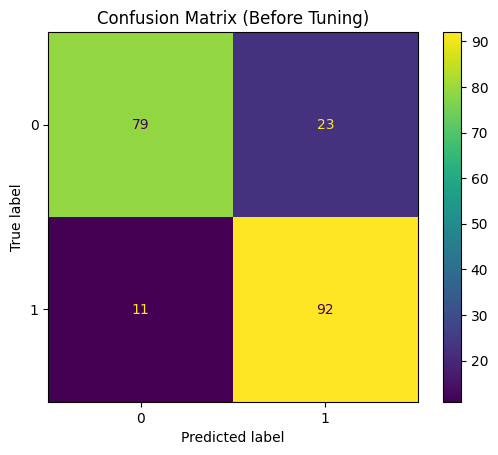


========== HYPERPARAMETER TUNING ==========
Best Parameters: {'n_neighbors': 15, 'weights': 'distance'}

Accuracy (After): 1.0

Classification Report (After):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       102
           1       1.00      1.00      1.00       103

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205



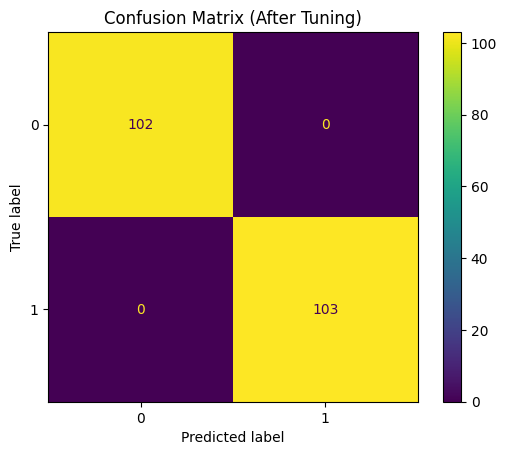

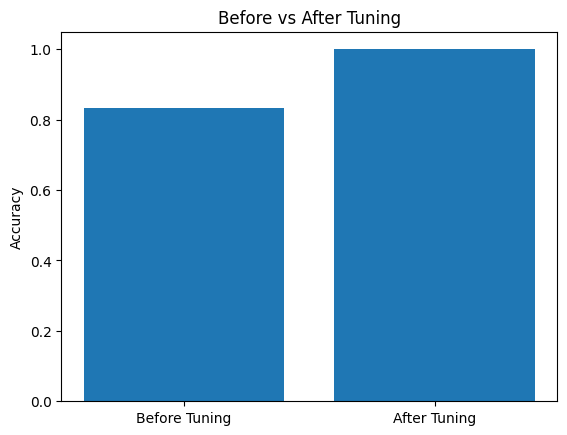

In [1]:
# ==========================================
# KNN - FINAL CODE (MATCHES DOCUMENT FORMAT)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# ==========================================
# STEP 1: LOAD DATA
# ==========================================
df = pd.read_csv('/content/heart.csv')

X = df.drop('target', axis=1)
y = df['target']

# ==========================================
# STEP 2: PREPROCESSING (SCALING)
# ==========================================
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ==========================================
# STEP 3: TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# STEP 4: MODEL TRAINING (BEFORE TUNING)
# ==========================================
print("\n========== BEFORE TUNING ==========")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# ==========================================
# STEP 5: PREDICTION (BEFORE)
# ==========================================
y_pred = knn.predict(X_test)

# ==========================================
# STEP 6: EVALUATION (BEFORE)
# ==========================================
acc_before = accuracy_score(y_test, y_pred)

print("\nAccuracy (Before):", acc_before)
print("\nClassification Report (Before):\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (Before Tuning)")
plt.show()

# ==========================================
# STEP 7: HYPERPARAMETER TUNING
# ==========================================
print("\n========== HYPERPARAMETER TUNING ==========")

params = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"]
}

knn_cv = GridSearchCV(KNeighborsClassifier(), params, cv=5)
knn_cv.fit(X_train, y_train)

print("Best Parameters:", knn_cv.best_params_)

# ==========================================
# STEP 8: MODEL TRAINING (AFTER TUNING)
# ==========================================
knn_best = knn_cv.best_estimator_

# ==========================================
# STEP 9: PREDICTION (AFTER)
# ==========================================
y_pred2 = knn_best.predict(X_test)

# ==========================================
# STEP 10: EVALUATION (AFTER)
# ==========================================
acc_after = accuracy_score(y_test, y_pred2)

print("\nAccuracy (After):", acc_after)
print("\nClassification Report (After):\n")
print(classification_report(y_test, y_pred2))

# Confusion Matrix (After)
cm2 = confusion_matrix(y_test, y_pred2)
ConfusionMatrixDisplay(cm2).plot()
plt.title("Confusion Matrix (After Tuning)")
plt.show()

# ==========================================
# STEP 11: COMPARISON GRAPH
# ==========================================
labels = ["Before Tuning", "After Tuning"]
values = [acc_before, acc_after]

plt.figure()
plt.bar(labels, values)
plt.ylabel("Accuracy")
plt.title("Before vs After Tuning")
plt.show()